# WSI Tile-Grid Environment (`wsi_env.py`) — Tutorial

This notebook provides a detailed walkthrough of the `WSIEnv` environment class built on top of the Gymnasium library — a reinforcement learning environment that abstracts a Whole Slide Image (WSI) as a tile-based grid world.

**Target audience**: Researchers interested in formulating WSI-based tumor detection as an RL problem.

**Contents**:
1. Environment Design Philosophy
2. HDF5 Database Structure Overview
3. Basic Usage: Creating the Environment, Observation & Action Spaces
4. Grid World Visualization: Tissue and Tumor Regions
5. Observation Vector Breakdown
6. Reward Mechanism and Termination Conditions
7. Starting Position Strategies (Fixed / Distance Band / Random Tissue)
8. Manually Interacting with the Environment
9. Integration with Stable-Baselines3

## 1. Environment Design Philosophy

Whole Slide Images (WSIs) in digital pathology are extremely high-resolution (tens of thousands × tens of thousands of pixels). Feeding raw WSI pixels directly into an RL environment is neither practical nor computationally feasible.

**Core idea**:
- Divide the WSI at 20× magnification into 224×224 pixel **tiles**
- Encode each tile with a pre-trained ResNet18 to obtain a 512-dimensional **embedding** vector
- Arrange all tiles spatially into a 2-D **grid world**
- The agent navigates the grid with the goal of locating a tumor region

This way, the agent's observation is a pre-computed feature vector rather than raw pixels, dramatically reducing computational cost.

```
WSI (high-resolution image)
    ↓ Tiling (224×224 tiles @ 20×)
Tile Grid (2-D grid)
    ↓ ResNet18 encoding
Embedding Grid (one 512-d vector per cell)
    ↓ Gymnasium environment
Agent navigates the grid → Goal: reach a tumor tile
```

Using RL to navigate and detect regions on WSIs remains an active research area. The tile-grid environment presented here is one of the most straightforward formulations: the large image is reduced to a discrete grid world and the agent takes discrete move actions.


## 2. Setup

Import the required libraries and specify an HDF5 database for a single WSI. We use `tumor_011` as the running example throughout this notebook.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import h5py

# Import the custom environment and utility function
from wsi_env import WSIEnv, find_starts_near_tumor

# Path to the HDF5 tile database for the example WSI
H5_PATH = "tile_database/tumor_011.h5"
EMBEDDING_SUFFIX = "_i"   # '_i' = ImageNet pretrained, '_s' = Self-Supervised


## 3. HDF5 Database Structure Overview

In the preceding notebooks (`(2)wsi_preprocessing.ipynb`, `(3)annotation_tile_visualization.ipynb`, `(4)h5_database_test.ipynb`), we stored the pre-processing results for each WSI into an HDF5 file. Let's inspect its internal structure:


In [2]:
with h5py.File(H5_PATH, "r") as f:
    print("=== HDF5 Datasets ===")
    for key in f.keys():
        ds = f[key]
        print(f"  {key:30s}  shape={str(ds.shape):16s}  dtype={ds.dtype}")
    print("\n=== HDF5 Attributes ===")
    for attr_name, attr_val in f.attrs.items():
        print(f"  {attr_name:25s} = {attr_val}")

=== HDF5 Datasets ===
  coords                          shape=(107474, 2)       dtype=int32
  embeddings_10x_i                shape=(107474, 512)     dtype=float32
  embeddings_10x_s                shape=(107474, 512)     dtype=float32
  embeddings_20x_i                shape=(107474, 512)     dtype=float32
  embeddings_20x_s                shape=(107474, 512)     dtype=float32
  thumbnail                       shape=(3456, 1528, 3)   dtype=uint8
  thumbnail_embedding_i           shape=(512,)            dtype=float32
  thumbnail_embedding_s           shape=(512,)            dtype=float32
  tissue_mask                     shape=(107474,)         dtype=bool
  tumor_mask                      shape=(107474,)         dtype=bool

=== HDF5 Attributes ===
  level_10x                 = 2
  level_20x                 = 1
  mpp                       = 0.24309399999999998
  slide_dimensions          = [ 97792 221184]
  tile_size                 = 224


**Key fields**:

| Field | Shape | Description |
|-------|-------|-------------|
| `embeddings_20x_i` / `_s` | (N, 512) | ResNet18 embeddings of 20× tiles (ImageNet / Self-Supervised) |
| `embeddings_10x_i` / `_s` | (N, 512) | Embeddings of 10× context images (same coordinates, wider field of view) |
| `coords` | (N, 2) | Absolute pixel coordinates (x, y) at level 0 for each tile |
| `tissue_mask` | (N,) | Whether each tile is a tissue region (non-background) |
| `tumor_mask` | (N,) | Whether each tile is tumor (area fraction ≥ 30%) |
| `thumbnail` | (H, W, 3) | Low-resolution WSI thumbnail |
| `thumbnail_embedding_i` / `_s` | (512,) | Embedding of the thumbnail image |


## 4. Creating an Environment Instance

`WSIEnv` loads the HDF5 data into memory and builds a grid world that the agent can interact with.


In [ ]:
# Create a basic environment instance
env = WSIEnv(
    h5_path=H5_PATH,
    max_steps=200,                 # Maximum steps per episode
    embedding_suffix=EMBEDDING_SUFFIX,
    enable_stop=False,             # STOP action disabled for now
)

print(f"Grid size:        {env.n_rows} rows x {env.n_cols} cols")
print(f"Total tiles:      {len(env.coords)}")
print(f"Tissue tiles:     {env.tissue_grid.sum()}")
print(f"Tumor tiles:      {env.tumor_grid.sum()}")
print(f"Tumor regions:    {env.n_tumor_regions}")
print(f"\nAction space:     {env.action_space}")
print(f"Observation space: {env.observation_space.shape}")


Grid size:        493 rows x 218 cols
Total tiles:      107474
Tissue tiles:     24347
Tumor tiles:      1108
Tumor regions:    13

Action space:     Discrete(4)
Observation space: (1660,)


The environment abstracts the WSI as an `n_rows × n_cols` grid. Only tissue tiles are reachable by the agent; tumor tiles are the targets.

### 4.1 Action Space

The agent's moves are straightforward:

| Action ID | Meaning | Grid movement |
|-----------|---------|---------------|
| 0 | UP | row − 1 |
| 1 | DOWN | row + 1 |
| 2 | LEFT | col − 1 |
| 3 | RIGHT | col + 1 |
| 4 | STOP | Stay in place and declare the current tile as tumor (only when `enable_stop=True`) |

If the agent tries to move outside the grid boundary or into a non-tissue tile, it is blocked and stays in place (wall bump).


## 5. Grid World Visualization

Visualize the tissue and tumor regions on the grid to get an intuitive picture of the agent's navigation space.


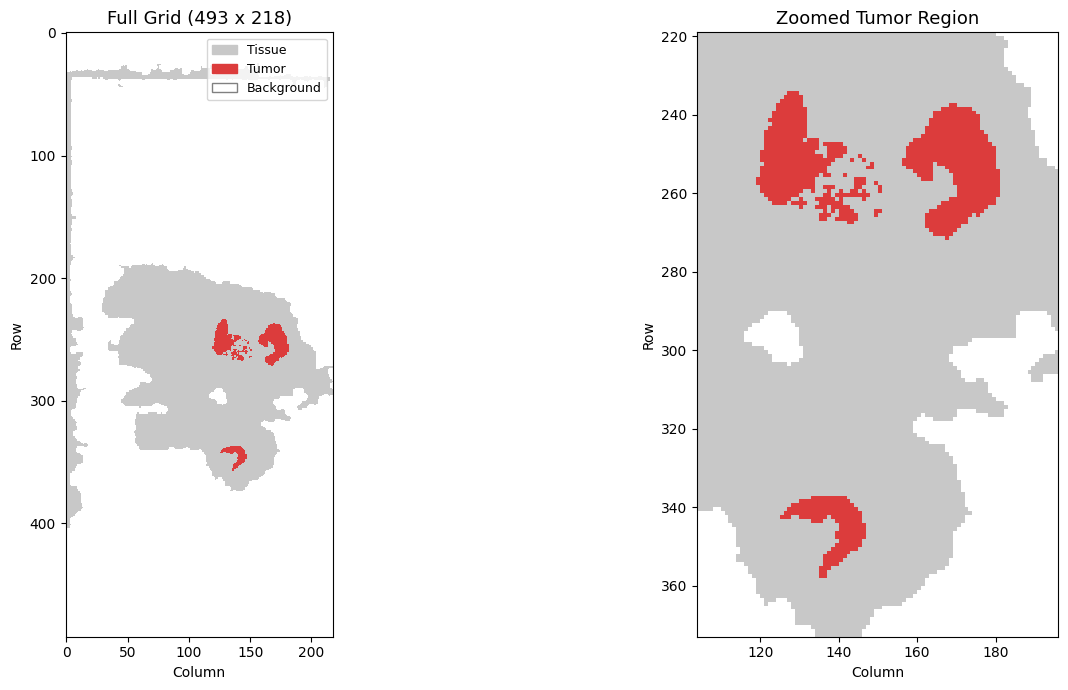

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left panel: full grid ---
ax = axes[0]
grid_vis = np.zeros((env.n_rows, env.n_cols, 3), dtype=np.uint8)
# Background = white
grid_vis[:] = 255
# Tissue region = light gray
grid_vis[env.tissue_grid] = [200, 200, 200]
# Tumor region = red
grid_vis[env.tumor_grid] = [220, 60, 60]

ax.imshow(grid_vis, interpolation='nearest')
ax.set_title(f"Full Grid ({env.n_rows} x {env.n_cols})", fontsize=13)
ax.set_xlabel("Column")
ax.set_ylabel("Row")

# Legend
legend_patches = [
    mpatches.Patch(color=[200/255, 200/255, 200/255], label='Tissue'),
    mpatches.Patch(color=[220/255, 60/255, 60/255], label='Tumor'),
    mpatches.Patch(color=[1, 1, 1], ec='gray', label='Background'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)

# --- Right panel: zoomed tumor region ---
ax = axes[1]
tumor_rows, tumor_cols = np.where(env.tumor_grid)
margin = 15  # extra tiles around the tumor bounding box
r_min = max(0, tumor_rows.min() - margin)
r_max = min(env.n_rows, tumor_rows.max() + margin + 1)
c_min = max(0, tumor_cols.min() - margin)
c_max = min(env.n_cols, tumor_cols.max() + margin + 1)

ax.imshow(grid_vis[r_min:r_max, c_min:c_max], interpolation='nearest',
          extent=[c_min, c_max, r_max, r_min])
ax.set_title("Zoomed Tumor Region", fontsize=13)
ax.set_xlabel("Column")
ax.set_ylabel("Row")

plt.tight_layout()
plt.show()


### 5.1 Connected Tumor Regions

When loading data, `WSIEnv` automatically detects connected tumor regions using `scipy.ndimage.label`. This is important for selecting starting positions in later sections.


In [5]:
from scipy import ndimage

print(f"Number of connected tumor regions: {env.n_tumor_regions}")
print()
for rid in range(1, env.n_tumor_regions + 1):
    region_mask = (env.tumor_labeled == rid)
    n_tiles = region_mask.sum()
    rows, cols = np.where(region_mask)
    print(f"  Region {rid}: {n_tiles} tiles, "
          f"rows [{rows.min()}-{rows.max()}], "
          f"cols [{cols.min()}-{cols.max()}]")

Number of connected tumor regions: 13

  Region 1: 350 tiles, rows [234-262], cols [119-141]
  Region 2: 485 tiles, rows [237-271], cols [156-180]
  Region 3: 1 tiles, rows [250-250], cols [145-145]
  Region 4: 1 tiles, rows [251-251], cols [143-143]
  Region 5: 1 tiles, rows [251-251], cols [146-146]
  Region 6: 3 tiles, rows [252-253], cols [147-148]
  Region 7: 1 tiles, rows [255-255], cols [141-141]
  Region 8: 72 tiles, rows [256-267], cols [134-147]
  Region 9: 1 tiles, rows [257-257], cols [149-149]
  Region 10: 2 tiles, rows [258-259], cols [150-150]
  Region 11: 6 tiles, rows [261-263], cols [128-131]
  Region 12: 3 tiles, rows [264-265], cols [149-150]
  Region 13: 182 tiles, rows [337-357], cols [125-146]


## 6. Observation Vector Breakdown

At every step, the agent receives an observation vector formed by concatenating the following components:

| Component | Dim | Description |
|-----------|-----|-------------|
| `embeddings_20x` | 512 | 20× embedding of the current tile |
| `embeddings_10x` | 512 | 10× context embedding at the same coordinates (wider field of view) |
| `thumbnail_embedding` | 512 | Global WSI thumbnail embedding (static throughout the episode) |
| `normalized_coord` | 2 | Normalized position (col/n_cols, row/n_rows) |
| `local_visited_map` | 121 | 11×11 local visitation record (radius=5) |
| `time_budget` | 1 | Current step / max_steps |
| **Total** | **1660** | |

Let's execute one reset and inspect each component:


In [ ]:
obs, info = env.reset(seed=42)

print(f"Observation shape: {obs.shape}")
print(f"Observation dtype: {obs.dtype}")
print(f"Observation range: [{obs.min():.4f}, {obs.max():.4f}]")
print()

# Decompose the observation into its individual components
emb_dim = 512
local_dim = (2 * env.local_radius + 1) ** 2  # 121

e20x   = obs[0 : emb_dim]                               # 20x embedding
e10x   = obs[emb_dim : 2*emb_dim]                       # 10x embedding
ethumb = obs[2*emb_dim : 3*emb_dim]                     # thumbnail embedding
coord  = obs[3*emb_dim : 3*emb_dim + 2]                 # normalized coord
vmap   = obs[3*emb_dim + 2 : 3*emb_dim + 2 + local_dim] # visited map
tbudget = obs[-1]                                        # time budget

print(f"--- Embedding components ---")
print(f"  20x embedding:       shape={e20x.shape}, norm={np.linalg.norm(e20x):.2f}")
print(f"  10x embedding:       shape={e10x.shape}, norm={np.linalg.norm(e10x):.2f}")
print(f"  Thumbnail embedding: shape={ethumb.shape}, norm={np.linalg.norm(ethumb):.2f}")
print(f"\n--- Spatial components ---")
print(f"  Normalized coord:    ({coord[0]:.4f}, {coord[1]:.4f})")
print(f"  Agent position:      row={info['row']}, col={info['col']}")
print(f"  Is tissue:           {info['is_tissue']}")
print(f"  Is tumor:            {info['is_tumor']}")
print(f"\n--- Visited map & time ---")
print(f"  Local visited map:   shape=({2*env.local_radius+1}x{2*env.local_radius+1}), "
      f"unique values={np.unique(vmap)}")
print(f"  Time budget:         {tbudget:.4f} (step {info['step']}/{env.max_steps})")


Observation shape: (1660,)
Observation dtype: float32
Observation range: [-1.0000, 6.3719]

--- Embedding components ---
  20x embedding:       shape=(512,), norm=10.71
  10x embedding:       shape=(512,), norm=17.02
  Thumbnail embedding: shape=(512,), norm=27.33

--- Spatial components ---
  Normalized coord:    (0.4608, 0.3943)
  Agent position:      row=194, col=100
  Is tissue:           True
  Is tumor:            False

--- Visited map & time ---
  Local visited map:   shape=(11x11), unique values=[-1.  0.  1.]
  Time budget:         0.0000 (step 0/200)


### 6.1 Local Visited Map Visualization

`local_visited_map` is an 11×11 window centered on the agent's current position that encodes the visitation state of nearby tiles:
- **0.0** — unvisited reachable tissue tile
- **1.0** — already visited tile
- **-1.0** — unreachable (outside grid boundary or non-tissue)


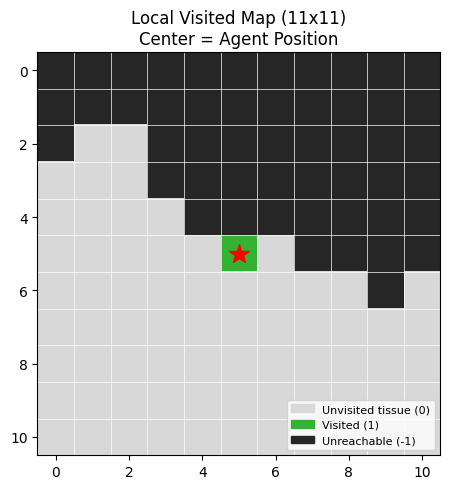

In [ ]:
# Reshape the visited map to 2-D and visualize
r = env.local_radius
vmap_2d = vmap.reshape(2*r+1, 2*r+1)

fig, ax = plt.subplots(figsize=(5, 5))

# Custom color mapping: -1=dark, 0=light gray, 1=green
vis_colors = np.zeros((*vmap_2d.shape, 3))
vis_colors[vmap_2d == -1] = [0.15, 0.15, 0.15]    # unreachable: dark
vis_colors[vmap_2d ==  0] = [0.85, 0.85, 0.85]    # unvisited tissue: light gray
vis_colors[vmap_2d ==  1] = [0.2, 0.7, 0.2]       # visited: green

ax.imshow(vis_colors, interpolation='nearest')
ax.set_title("Local Visited Map (11x11)\nCenter = Agent Position", fontsize=12)

# Mark the center cell (agent's current position)
ax.plot(r, r, 'r*', markersize=15, label='Agent')
ax.legend(loc='upper right')

# Add grid lines
for i in range(2*r+2):
    ax.axhline(i - 0.5, color='white', linewidth=0.5)
    ax.axvline(i - 0.5, color='white', linewidth=0.5)

legend_patches = [
    mpatches.Patch(color=[0.85, 0.85, 0.85], label='Unvisited tissue (0)'),
    mpatches.Patch(color=[0.2, 0.7, 0.2], label='Visited (1)'),
    mpatches.Patch(color=[0.15, 0.15, 0.15], label='Unreachable (-1)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


## 7. Reward Mechanism and Termination Conditions

The reward design balances exploration efficiency with goal achievement:

| Signal | Default | Trigger |
|--------|---------|---------|
| `step_penalty` | −0.01 | Applied every step (encourages efficiency) |
| `revisit_penalty` | −0.2 | Stepping onto an already-visited tile |
| `background_penalty` | −0.5 | Stepping onto a non-tissue tile (guarded by wall-bump, kept as a safety fallback) |
| `tumor_reward` | +50.0 | Agent steps onto a tumor tile (external termination mode) |
| `timeout_penalty` | −1.0 | Episode reaches `max_steps` |
| `stop_correct` | +100.0 | STOP on a tumor tile (requires `enable_stop=True`) |
| `stop_wrong` | −50.0 | STOP on a non-tumor tile |

### Termination Conditions

An episode ends when:
1. **External termination**: agent moves onto a tumor tile → `terminated=True`
2. **STOP action** (if enabled): correct or incorrect → `terminated=True`
3. **Timeout**: `max_steps` reached → `truncated=True`


In [ ]:
# Inspect the reward configuration for this environment instance
print("=== Reward Configuration ===")
for k, v in env.reward_cfg.items():
    print(f"  {k:25s} = {v}")


=== Reward Configuration ===
  step_penalty              = -0.01
  background_penalty        = -0.5
  revisit_penalty           = -0.2
  tumor_reward              = 50.0
  timeout_penalty           = -1.0
  stop_correct              = 100.0
  stop_wrong                = -50.0


## 8. Starting Position Strategies

`WSIEnv` supports three starting position modes for different experimental phases:

| `start_mode` | Description | Use case |
|--------------|-------------|----------|
| `"fixed"` | Cycle through the provided `fixed_starts` list | Baseline convergence verification |
| `"distance_band"` | Sample randomly from tissue tiles within BFS distance `[d_min, d_max]` from tumor | Curriculum Learning |
| `"random_tissue"` | Sample from any non-tumor tissue tile | Final evaluation |

### 8.1 Selecting Fixed Starting Positions with `find_starts_near_tumor`

This utility function uses morphological dilation to select starting positions near the tumor boundary:


In [ ]:
# Select one starting position per connected tumor region, ~4 steps from the boundary
fixed_starts = find_starts_near_tumor(
    env,
    distance=4,           # Number of dilation iterations from the tumor boundary
    n_per_region=1,       # Starting positions per connected region
    min_region_size=20,   # Ignore regions smaller than 20 tiles
    seed=42,
)

print(f"Selected {len(fixed_starts)} fixed starting position(s):")
for i, (r, c) in enumerate(fixed_starts):
    idx = env._rc_to_idx(r, c)
    print(f"  Start {i}: row={r}, col={c}, "
          f"tissue={env.tissue_grid[r, c]}, tumor={env.tumor_grid[r, c]}")


Selected 4 fixed starting position(s):
  Start 0: row=243, col=140, tissue=True, tumor=False
  Start 1: row=240, col=179, tissue=True, tumor=False
  Start 2: row=268, col=133, tissue=True, tumor=False
  Start 3: row=334, col=142, tissue=True, tumor=False


### 8.2 BFS Distance and the Distance Band Mode

Internally, `WSIEnv` runs a BFS (breadth-first search) over the tissue grid to compute the shortest grid-path distance from each tissue tile to the nearest tumor tile. This distance map is used in Curriculum Learning to gradually increase the starting distance from the tumor.


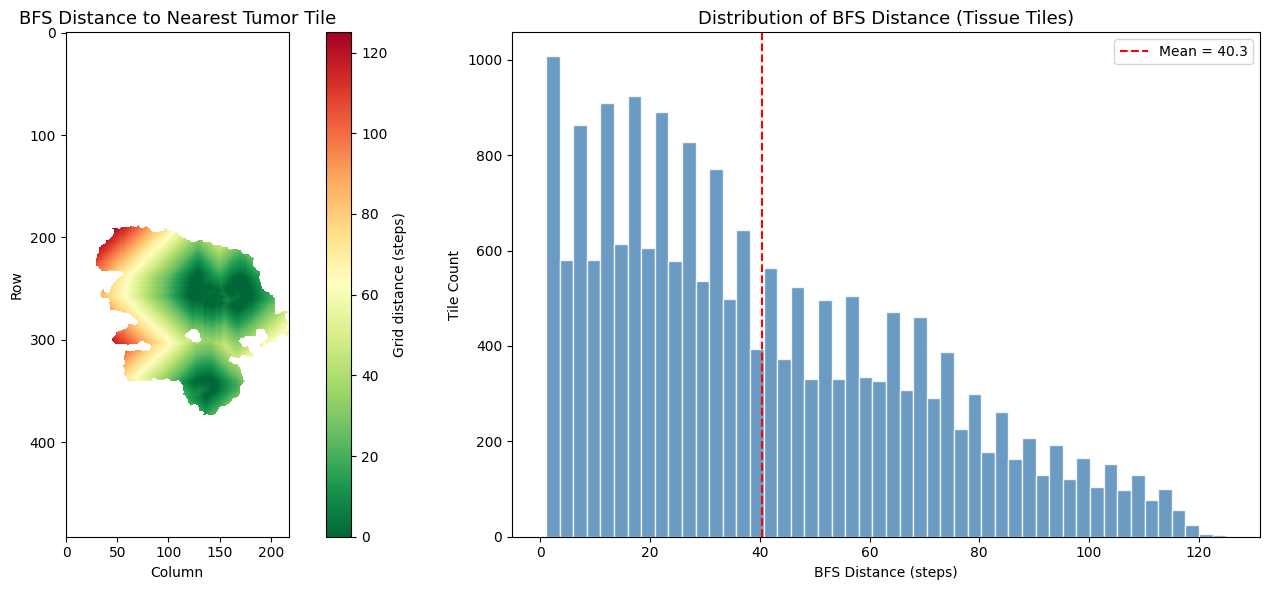

  Distance [ 3,  5]:   884 candidate tiles
  Distance [ 5, 10]:  1733 candidate tiles
  Distance [10, 20]:  3343 candidate tiles
  Distance [20, 50]:  7228 candidate tiles


In [ ]:
# Compute the BFS distance map
env._compute_distance_to_tumor()
dist_map = env._dist_to_tumor

# Collect distances for tissue tiles only (excluding tumor tiles)
tissue_dists = dist_map[env.tissue_grid & ~env.tumor_grid]
tissue_dists = tissue_dists[tissue_dists >= 0]  # drop unreachable tiles (-1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left panel: distance heatmap ---
ax = axes[0]
display_dist = dist_map.astype(float).copy()
display_dist[dist_map == -1] = np.nan  # show unreachable tiles as empty
display_dist[env.tumor_grid] = 0

im = ax.imshow(display_dist, cmap='RdYlGn_r', interpolation='nearest')
ax.set_title("BFS Distance to Nearest Tumor Tile", fontsize=13)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.colorbar(im, ax=ax, label='Grid distance (steps)')

# --- Right panel: distance distribution histogram ---
ax = axes[1]
ax.hist(tissue_dists, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title("Distribution of BFS Distance (Tissue Tiles)", fontsize=13)
ax.set_xlabel("BFS Distance (steps)")
ax.set_ylabel("Tile Count")
ax.axvline(tissue_dists.mean(), color='red', linestyle='--',
           label=f'Mean = {tissue_dists.mean():.1f}')
ax.legend()

plt.tight_layout()
plt.show()

# Number of candidate tiles in each distance band
for d_min, d_max in [(3, 5), (5, 10), (10, 20), (20, 50)]:
    pool = env.get_start_pool(d_min, d_max)
    print(f"  Distance [{d_min:2d}, {d_max:2d}]: {len(pool):5d} candidate tiles")


### 8.3 Spatial Relationship Between Starting Positions and Tumor


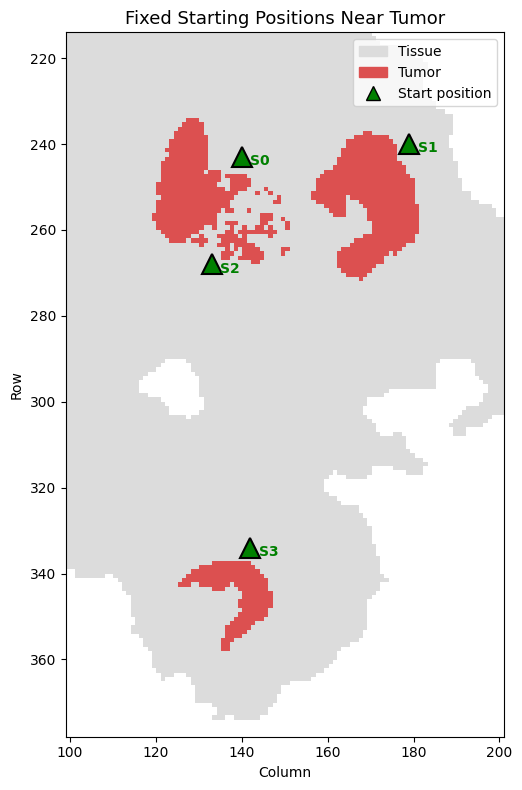

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# Build background grid image
grid_vis = np.zeros((env.n_rows, env.n_cols, 3), dtype=np.uint8)
grid_vis[:] = 255
grid_vis[env.tissue_grid] = [220, 220, 220]
grid_vis[env.tumor_grid] = [220, 80, 80]

# Zoom to the tumor neighbourhood
tumor_rows, tumor_cols = np.where(env.tumor_grid)
margin = 20
r_min = max(0, tumor_rows.min() - margin)
r_max = min(env.n_rows, tumor_rows.max() + margin + 1)
c_min = max(0, tumor_cols.min() - margin)
c_max = min(env.n_cols, tumor_cols.max() + margin + 1)

ax.imshow(grid_vis[r_min:r_max, c_min:c_max], interpolation='nearest',
          extent=[c_min, c_max, r_max, r_min])

# Mark fixed start positions
for i, (sr, sc) in enumerate(fixed_starts):
    ax.plot(sc, sr, 'g^', markersize=14, markeredgecolor='black', markeredgewidth=1.5)
    ax.annotate(f'S{i}', (sc, sr), textcoords="offset points",
                xytext=(6, -6), fontsize=10, fontweight='bold', color='green')

ax.set_title("Fixed Starting Positions Near Tumor", fontsize=13)
ax.set_xlabel("Column")
ax.set_ylabel("Row")

legend_patches = [
    mpatches.Patch(color=[220/255, 220/255, 220/255], label='Tissue'),
    mpatches.Patch(color=[220/255, 80/255, 80/255], label='Tumor'),
    plt.Line2D([], [], marker='^', color='green', linestyle='None',
               markersize=10, markeredgecolor='black', label='Start position'),
]
ax.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()


## 9. Manually Interacting with the Environment

Before training an RL agent, it is helpful to step through the environment manually and observe its feedback mechanisms first-hand.

### 9.1 Step-by-Step Walkthrough


In [ ]:
# Create an environment with fixed starting positions
demo_env = WSIEnv(
    h5_path=H5_PATH,
    max_steps=200,
    embedding_suffix=EMBEDDING_SUFFIX,
    enable_stop=False,
    fixed_starts=fixed_starts,
    start_mode="fixed",
)

obs, info = demo_env.reset(seed=0)
print(f"=== Episode Start ===")
print(f"Position: row={info['row']}, col={info['col']}")
print(f"Tissue: {info['is_tissue']}, Tumor: {info['is_tumor']}")
print()

# Execute 5 manual actions (UP=0, DOWN=1, LEFT=2, RIGHT=3)
ACTION_NAMES = {0: 'UP', 1: 'DOWN', 2: 'LEFT', 3: 'RIGHT', 4: 'STOP'}
manual_actions = [1, 1, 3, 0, 2]  # DOWN, DOWN, RIGHT, UP, LEFT

total_reward = 0.0
for step_i, action in enumerate(manual_actions, 1):
    obs, reward, terminated, truncated, info = demo_env.step(action)
    total_reward += reward
    status = "TUMOR FOUND!" if terminated and info['is_tumor'] else \
             "TIMEOUT" if truncated else "ongoing"
    print(f"Step {step_i}: action={ACTION_NAMES[action]:5s} -> "
          f"pos=({info['row']:3d}, {info['col']:3d}), "
          f"reward={reward:+.2f}, visited={info['n_visited']}, "
          f"status={status}")
    if terminated or truncated:
        break

print(f"\nTotal reward after {step_i} steps: {total_reward:.2f}")


=== Episode Start ===
Position: row=243, col=140
Tissue: True, Tumor: False

Step 1: action=DOWN  -> pos=(244, 140), reward=-0.01, visited=2, status=ongoing
Step 2: action=DOWN  -> pos=(245, 140), reward=-0.01, visited=3, status=ongoing
Step 3: action=RIGHT -> pos=(245, 141), reward=-0.01, visited=4, status=ongoing
Step 4: action=UP    -> pos=(244, 141), reward=-0.01, visited=5, status=ongoing
Step 5: action=LEFT  -> pos=(244, 140), reward=-0.21, visited=5, status=ongoing

Total reward after 5 steps: -0.25


### 9.2 Random Policy Rollout

Run a full episode with a random policy to observe the agent's behavior pattern and the environment's feedback:


In [ ]:
obs, info = demo_env.reset(seed=0)
trajectory = [(info['row'], info['col'])]
rewards = []
done = False
step = 0

rng = np.random.default_rng(123)

while not done:
    action = rng.integers(0, 4)  # randomly choose from {0, 1, 2, 3}
    obs, reward, terminated, truncated, info = demo_env.step(action)
    trajectory.append((info['row'], info['col']))
    rewards.append(reward)
    done = terminated or truncated
    step += 1

print(f"Episode finished in {step} steps")
print(f"Total reward: {sum(rewards):.2f}")
print(f"Final position: row={info['row']}, col={info['col']}")
print(f"Success (found tumor): {info.get('success', False)}")
print(f"Unique tiles visited: {info['n_visited']}")


Episode finished in 136 steps
Total reward: 34.84
Final position: row=247, col=178
Success (found tumor): True
Unique tiles visited: 68


### 9.3 Trajectory Visualization

Plot the random-policy agent's navigation path on the tile grid:


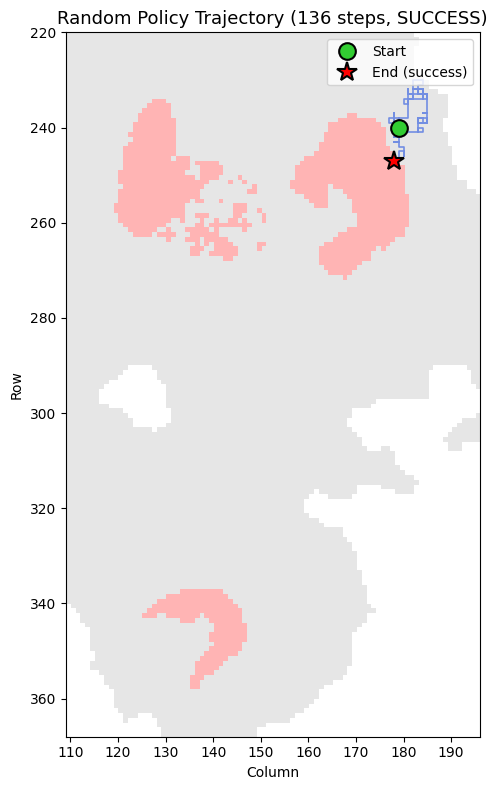

In [ ]:
traj = np.array(trajectory)

# Determine the visualization bounding box
all_rows = np.concatenate([traj[:, 0], tumor_rows])
all_cols = np.concatenate([traj[:, 1], tumor_cols])
margin = 10
r_lo = max(0, all_rows.min() - margin)
r_hi = min(env.n_rows, all_rows.max() + margin + 1)
c_lo = max(0, all_cols.min() - margin)
c_hi = min(env.n_cols, all_cols.max() + margin + 1)

fig, ax = plt.subplots(figsize=(10, 8))

# Build the background grid
grid_vis_local = np.zeros((env.n_rows, env.n_cols, 3), dtype=np.uint8)
grid_vis_local[:] = 255
grid_vis_local[env.tissue_grid] = [230, 230, 230]
grid_vis_local[env.tumor_grid] = [255, 180, 180]

ax.imshow(grid_vis_local[r_lo:r_hi, c_lo:c_hi], interpolation='nearest',
          extent=[c_lo, c_hi, r_hi, r_lo])

# Trajectory line
ax.plot(traj[:, 1], traj[:, 0], '-', color='royalblue', linewidth=1.2, alpha=0.7)

# Start and end markers
ax.plot(traj[0, 1], traj[0, 0], 'o', color='limegreen', markersize=12,
        markeredgecolor='black', markeredgewidth=1.5, label='Start', zorder=5)
end_color = 'red' if info.get('success', False) else 'orange'
end_marker = '*' if info.get('success', False) else 'X'
ax.plot(traj[-1, 1], traj[-1, 0], end_marker, color=end_color, markersize=15,
        markeredgecolor='black', markeredgewidth=1.5,
        label='End (success)' if info.get('success', False) else 'End (timeout)',
        zorder=5)

ax.set_title(f"Random Policy Trajectory ({step} steps, "
             f"{'SUCCESS' if info.get('success', False) else 'TIMEOUT'})", fontsize=13)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 10. Integration with Stable-Baselines3

`WSIEnv` is fully compatible with the Gymnasium API and can be plugged directly into Stable-Baselines3 (SB3) or any other library that follows the same standard.

### 10.1 Environment Compliance Check

SB3 provides a `check_env` utility to verify that the environment conforms to the Gymnasium specification:


In [ ]:
from stable_baselines3.common.env_checker import check_env

test_env = WSIEnv(
    h5_path=H5_PATH,
    max_steps=200,
    embedding_suffix=EMBEDDING_SUFFIX,
    enable_stop=False,
    fixed_starts=fixed_starts,
    start_mode="fixed",
)

# check_env validates observation/action space definitions and reset/step return formats
check_env(test_env, warn=True)
print("Environment check passed!")


Environment check passed!


### 10.2 Training a PPO Agent (Quick Demo)

The following shows how to train a PPO agent with SB3. This is a **short demo** (10,000 steps only). For full training results, see `(5)RL_setup_and_Single_WSI.ipynb`.


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# Create the training environment
train_env = WSIEnv(
    h5_path=H5_PATH,
    max_steps=200,
    embedding_suffix=EMBEDDING_SUFFIX,
    enable_stop=False,
    fixed_starts=fixed_starts,
    start_mode="fixed",
    reward_cfg=dict(
        step_penalty=-0.01,
        revisit_penalty=-0.2,
        tumor_reward=50.0,
        timeout_penalty=-1.0,
        background_penalty=-0.5,
    ),
)
train_env = Monitor(train_env)  # wrap to log episode statistics

# Build the PPO model
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=0,
)

print(f"Model policy: {model.policy_class.__name__}")
print(f"Observation dim: {model.observation_space.shape[0]}")
print(f"Action dim: {model.action_space.n}")


Model policy: ActorCriticPolicy
Observation dim: 1660
Action dim: 4


d:\ProgramData\Anaconda3\envs\wsi-rl\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [ ]:
# Short training demo (10K steps)
print("Training for 10,000 timesteps (demo) ...")
model.learn(total_timesteps=10_000)
print("Training complete.")

# Summarize episode statistics logged by Monitor
ep_rewards = train_env.get_episode_rewards()
ep_lengths = train_env.get_episode_lengths()
print(f"\nCompleted {len(ep_rewards)} episodes during training")
if len(ep_rewards) > 0:
    print(f"  Mean reward:  {np.mean(ep_rewards):.2f}")
    print(f"  Mean length:  {np.mean(ep_lengths):.1f}")
    n_success = sum(1 for r in ep_rewards if r > 0)
    print(f"  Success rate: {n_success}/{len(ep_rewards)} "
          f"({100*n_success/len(ep_rewards):.1f}%)")


Training for 10,000 timesteps (demo) ...
Training complete.

Completed 382 episodes during training
  Mean reward:  44.68
  Mean length:  26.8
  Success rate: 361/382 (94.5%)


### 10.3 Deterministic Inference with the Trained Model

After training, use `model.predict()` to run the agent deterministically:


Deterministic rollout: 4 steps
Total reward: 49.96
Success: True


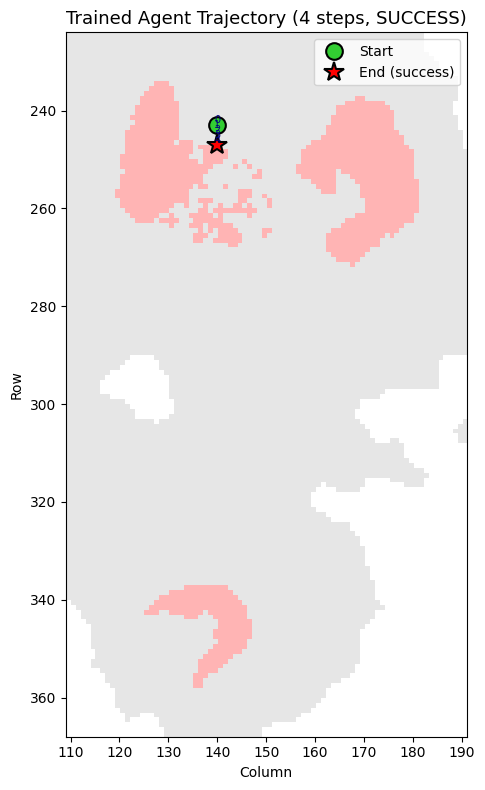

In [ ]:
# Run one deterministic rollout with the trained model
eval_env = WSIEnv(
    h5_path=H5_PATH,
    max_steps=200,
    embedding_suffix=EMBEDDING_SUFFIX,
    enable_stop=False,
    fixed_starts=fixed_starts,
    start_mode="fixed",
)

obs, info = eval_env.reset(seed=0)
eval_traj = [(info['row'], info['col'])]
eval_rewards = []
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    eval_traj.append((info['row'], info['col']))
    eval_rewards.append(reward)
    done = terminated or truncated

print(f"Deterministic rollout: {len(eval_rewards)} steps")
print(f"Total reward: {sum(eval_rewards):.2f}")
print(f"Success: {info.get('success', False)}")

# Plot the trajectory
eval_traj = np.array(eval_traj)
fig, ax = plt.subplots(figsize=(10, 8))

all_r = np.concatenate([eval_traj[:, 0], tumor_rows])
all_c = np.concatenate([eval_traj[:, 1], tumor_cols])
m = 10
r_lo = max(0, all_r.min() - m)
r_hi = min(env.n_rows, all_r.max() + m + 1)
c_lo = max(0, all_c.min() - m)
c_hi = min(env.n_cols, all_c.max() + m + 1)

bg = np.full((env.n_rows, env.n_cols, 3), 255, dtype=np.uint8)
bg[env.tissue_grid] = [230, 230, 230]
bg[env.tumor_grid] = [255, 180, 180]

ax.imshow(bg[r_lo:r_hi, c_lo:c_hi], interpolation='nearest',
          extent=[c_lo, c_hi, r_hi, r_lo])
ax.plot(eval_traj[:, 1], eval_traj[:, 0], '-', color='royalblue', linewidth=1.5)
ax.plot(eval_traj[0, 1], eval_traj[0, 0], 'o', color='limegreen',
        markersize=12, markeredgecolor='black', markeredgewidth=1.5, label='Start')
end_c = 'red' if info.get('success', False) else 'orange'
end_m = '*' if info.get('success', False) else 'X'
ax.plot(eval_traj[-1, 1], eval_traj[-1, 0], end_m, color=end_c,
        markersize=15, markeredgecolor='black', markeredgewidth=1.5,
        label='End (success)' if info.get('success', False) else 'End (timeout)')

# Annotate step indices at regular intervals
for i in range(0, len(eval_traj), max(1, len(eval_traj)//10)):
    ax.annotate(str(i), (eval_traj[i, 1], eval_traj[i, 0]),
                fontsize=7, color='navy', ha='center', va='bottom')

ax.set_title(f"Trained Agent Trajectory ({len(eval_rewards)} steps, "
             f"{'SUCCESS' if info.get('success', False) else 'TIMEOUT'})", fontsize=13)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 11. Parameter Reference

A complete summary of all `WSIEnv` constructor parameters and their defaults:

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `h5_path` | str | (required) | Path to the HDF5 tile database |
| `max_steps` | int | 2000 | Maximum steps per episode |
| `embedding_suffix` | str | `"_i"` | Embedding type: `"_i"` (ImageNet) or `"_s"` (Self-Supervised) |
| `local_radius` | int | 5 | Radius of the local visited map (yields an 11×11 window) |
| `enable_stop` | bool | False | Whether to include the STOP action |
| `fixed_starts` | list | None | Fixed starting positions as a list of (row, col) tuples |
| `start_mode` | str | `"fixed"` | Starting mode: `"fixed"` / `"distance_band"` / `"random_tissue"` |
| `start_dist_range` | tuple | None | `(d_min, d_max)` for the distance band mode |
| `reward_cfg` | dict | None | Override any default reward hyperparameters |

### Source Code

See [wsi_env.py](wsi_env.py) for the full implementation. It contains:
- `WSIEnv` — the complete Gymnasium environment class
- `find_starts_near_tumor()` — utility to select fixed starting positions via morphological dilation